# **HW8: Decision Trees**

#### **Attention:** *This assignment is to be completed individually. Group work is not permitted.*

# **Decision Trees for Classification and Regression**

In this notebook exercise, we will explore **Decision Trees** using scikit-learn to understand how tree-based models make predictions and how hyperparameters affect model complexity.

## **What are Decision Trees?**

Decision Trees are a fundamental machine learning algorithm that can be used for both **classification** and **regression** tasks. They work by:
- Recursively splitting the data based on feature values
- Creating a tree structure where each internal node represents a "decision" based on a feature
- Each leaf node represents a prediction (class label or value)

## **Key Hyperparameter: min_samples_split**

One important hyperparameter is `min_samples_split`:
- **Definition**: The minimum number of samples required to split an internal node
- **Small values** (e.g., 2): Allow more splits, creating deeper/larger trees
- **Large values** (e.g., 50): Restrict splits, creating shallower/smaller trees

This hyperparameter controls the **bias-variance tradeoff**:
- **Large trees**: Low bias, high variance (may overfit)
- **Small trees**: High bias, low variance (may underfit)

## **Objectives**

In this exercise, you will:
1. Load a classification dataset and explore its properties
2. Train classification decision trees with different `min_samples_split` values
3. Analyze the tradeoff between tree size and accuracy
4. Load a regression dataset and explore its properties
5. Train regression decision trees with different `min_samples_split` values
6. Analyze the tradeoff between tree size and prediction error

## **Import Libraries**

Let's start by importing the necessary libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


---
# **Part 1: Classification Decision Trees**
---

## **TASK 1: Load and Explore the Classification Dataset**

We will use the **Wine dataset** from scikit-learn. This dataset contains chemical analysis results of wines grown in the same region but derived from three different cultivars.

Load the dataset and print:
- The shape of the feature matrix (X)
- The shape of the target vector (y)
- The feature names
- The target class names
- Basic statistics about the features

In [2]:
# Load the Wine dataset
wine = datasets.load_wine()
X_class = wine.data
y_class = wine.target

print("Wine Classification Dataset")
print("="*50)
print(f"\nFeature matrix shape: {X_class.shape}")
print(f"Target vector shape: {y_class.shape}")
print(f"\nNumber of samples: {X_class.shape[0]}")
print(f"Number of features: {X_class.shape[1]}")
print(f"Number of classes: {len(wine.target_names)}")

print(f"\nFeature names:")
for i, name in enumerate(wine.feature_names):
    print(f"  {i+1}. {name}")

print(f"\nTarget class names: {list(wine.target_names)}")

print(f"\nClass distribution:")
for i, name in enumerate(wine.target_names):
    count = np.sum(y_class == i)
    print(f"  Class {i} ({name}): {count} samples ({100*count/len(y_class):.1f}%)")

Wine Classification Dataset

Feature matrix shape: (178, 13)
Target vector shape: (178,)

Number of samples: 178
Number of features: 13
Number of classes: 3

Feature names:
  1. alcohol
  2. malic_acid
  3. ash
  4. alcalinity_of_ash
  5. magnesium
  6. total_phenols
  7. flavanoids
  8. nonflavanoid_phenols
  9. proanthocyanins
  10. color_intensity
  11. hue
  12. od280/od315_of_diluted_wines
  13. proline

Target class names: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
  Class 0 (class_0): 59 samples (33.1%)
  Class 1 (class_1): 71 samples (39.9%)
  Class 2 (class_2): 48 samples (27.0%)


In [3]:
# Print basic statistics about the features
print("\nFeature Statistics:")
print("="*80)
print(f"{'Feature':<25} {'Min':>10} {'Max':>10} {'Mean':>10} {'Std':>10}")
print("-"*80)
for i, name in enumerate(wine.feature_names):
    print(f"{name:<25} {X_class[:,i].min():>10.2f} {X_class[:,i].max():>10.2f} {X_class[:,i].mean():>10.2f} {X_class[:,i].std():>10.2f}")


Feature Statistics:
Feature                          Min        Max       Mean        Std
--------------------------------------------------------------------------------
alcohol                        11.03      14.83      13.00       0.81
malic_acid                      0.74       5.80       2.34       1.11
ash                             1.36       3.23       2.37       0.27
alcalinity_of_ash              10.60      30.00      19.49       3.33
magnesium                      70.00     162.00      99.74      14.24
total_phenols                   0.98       3.88       2.30       0.62
flavanoids                      0.34       5.08       2.03       1.00
nonflavanoid_phenols            0.13       0.66       0.36       0.12
proanthocyanins                 0.41       3.58       1.59       0.57
color_intensity                 1.28      13.00       5.06       2.31
hue                             0.48       1.71       0.96       0.23
od280/od315_of_diluted_wines       1.27       4.00       2

## **TASK 2: Split the Data into Training and Test Sets**

Split the classification data into training and test sets using the train_test_split() function.

Use:
- 70% of data for training
- 30% of data for testing
- `random_state=42` for reproducibility
- `stratify=y_class` to maintain class proportions

In [4]:
# Write your code here

# Split the data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.3,
    random_state=42,
    stratify=y_class
)

print(f"Training set size: {len(X_train_class)} samples")
print(f"Test set size: {len(X_test_class)} samples")

print(f"\nTraining set class distribution:")
for i, name in enumerate(wine.target_names):
    count = np.sum(y_train_class == i)
    print(f"  Class {i} ({name}): {count} samples")

print(f"\nTest set class distribution:")
for i, name in enumerate(wine.target_names):
    count = np.sum(y_test_class == i)
    print(f"  Class {i} ({name}): {count} samples")

Training set size: 124 samples
Test set size: 54 samples

Training set class distribution:
  Class 0 (class_0): 41 samples
  Class 1 (class_1): 50 samples
  Class 2 (class_2): 33 samples

Test set class distribution:
  Class 0 (class_0): 18 samples
  Class 1 (class_1): 21 samples
  Class 2 (class_2): 15 samples


## **TASK 3: Train Classification Decision Trees with Different min_samples_split Values**

Train multiple decision tree classifiers using different values of `min_samples_split`.

For each tree, record:
- The `min_samples_split` value used
- The total number of nodes in the tree (tree size)
- The training accuracy
- The test accuracy

Use the following values for `min_samples_split`: [2, 5, 10, 15, 20, 30, 40, 50]

**Hints**:
- Use `DecisionTreeClassifier(min_samples_split=value, random_state=42)`
- Tree size can be obtained from `clf.tree_.node_count`
- Use `accuracy_score()` to calculate accuracy

In [6]:
# Write your code here

# Define min_samples_split values to test
min_samples_splits = [2, 20, 40, 50]

# Lists to store results
class_tree_sizes = []
class_train_accuracies = []
class_test_accuracies = []

print("Classification Decision Tree Results")
print("="*70)
print(f"{'min_samples_split':>18} {'Tree Size':>12} {'Train Acc':>12} {'Test Acc':>12}")
print("-"*70)

for min_split in min_samples_splits:
    # Create and train the classifier
    clf = DecisionTreeClassifier(min_samples_split=min_split, random_state=42)
    clf.fit(X_train_class, y_train_class)
    
    # Get tree size
    tree_size = clf.tree_.node_count
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train_class, clf.predict(X_train_class))
    test_acc = accuracy_score(y_test_class, clf.predict(X_test_class))
    
    # Store results
    class_tree_sizes.append(tree_size)
    class_train_accuracies.append(train_acc)
    class_test_accuracies.append(test_acc)
    
    print(f"{min_split:>18} {tree_size:>12} {train_acc:>12.4f} {test_acc:>12.4f}")

print("\nDone! Results stored for plotting.")

Classification Decision Tree Results
 min_samples_split    Tree Size    Train Acc     Test Acc
----------------------------------------------------------------------
                 2           15       1.0000       0.9630
                20           13       0.9919       0.9630
                40           11       0.9839       0.9815
                50            5       0.9274       0.8889

Done! Results stored for plotting.


## **TASK 4: Plot the Classification Results**

Create a plot showing the relationship between tree size and accuracy.

Your plot should show:
- X-axis: Tree size (number of nodes)
- Y-axis: Accuracy
- Two lines: one for training accuracy, one for test accuracy
- Appropriate labels, title, and legend

**Question to consider**: What do you observe about the gap between training and test accuracy as tree size increases?

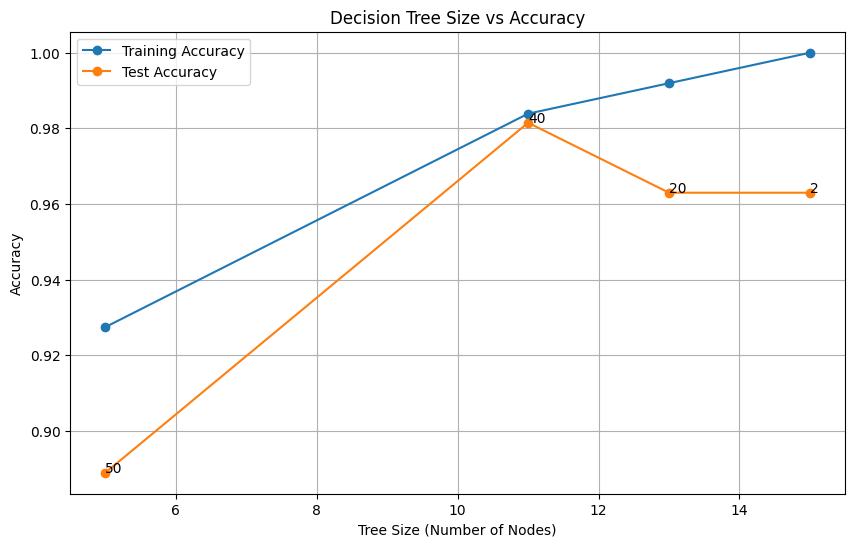

In [7]:
# Write your code here

plt.figure(figsize=(10, 6))

# Plot training and test accuracy vs tree size
plt.plot(class_tree_sizes, class_train_accuracies, marker='o', label='Training Accuracy')
plt.plot(class_tree_sizes, class_test_accuracies, marker='o', label='Test Accuracy')

for i, split in enumerate(min_samples_splits):
    plt.text(class_tree_sizes[i], class_test_accuracies[i], str(split))

# Add labels for min_samples_split values
plt.xlabel("Tree Size (Number of Nodes)")
plt.ylabel("Accuracy")
plt.title("Decision Tree Size vs Accuracy")
plt.legend()
plt.grid(True)
plt.show()


## **TASK 4.1: QUESTION**

Based on the plot above, what is the relationship between tree size and the gap between training and test accuracy? What does this tell us about overfitting?

As tree size increases (smaller min_samples_split values), the training accuracy approaches 100% while the test accuracy may not improve or can even decrease. This growing gap between training and test accuracy indicates overfitting - the larger trees are memorizing the training data rather than learning generalizable patterns. Smaller trees (larger min_samples_split) tend to generalize better to unseen data.

---
# **Part 2: Regression Decision Trees**
---

## **TASK 5: Load and Explore the Regression Dataset**

We will use the **California Housing dataset** from scikit-learn. This dataset contains information about housing districts in California, and the target is the median house value.

Load the dataset and print:
- The shape of the feature matrix (X)
- The shape of the target vector (y)
- The feature names
- Basic statistics about the features and target

In [8]:
# Load the California Housing dataset
housing = datasets.fetch_california_housing()
X_reg = housing.data
y_reg = housing.target

print("California Housing Regression Dataset")
print("="*50)
print(f"\nFeature matrix shape: {X_reg.shape}")
print(f"Target vector shape: {y_reg.shape}")
print(f"\nNumber of samples: {X_reg.shape[0]}")
print(f"Number of features: {X_reg.shape[1]}")

print(f"\nFeature names:")
for i, name in enumerate(housing.feature_names):
    print(f"  {i+1}. {name}")

print(f"\nTarget: Median house value (in $100,000s)")

California Housing Regression Dataset

Feature matrix shape: (20640, 8)
Target vector shape: (20640,)

Number of samples: 20640
Number of features: 8

Feature names:
  1. MedInc
  2. HouseAge
  3. AveRooms
  4. AveBedrms
  5. Population
  6. AveOccup
  7. Latitude
  8. Longitude

Target: Median house value (in $100,000s)


In [9]:
# Print basic statistics about the features
print("\nFeature Statistics:")
print("="*80)
print(f"{'Feature':<15} {'Min':>12} {'Max':>12} {'Mean':>12} {'Std':>12}")
print("-"*80)
for i, name in enumerate(housing.feature_names):
    print(f"{name:<15} {X_reg[:,i].min():>12.2f} {X_reg[:,i].max():>12.2f} {X_reg[:,i].mean():>12.2f} {X_reg[:,i].std():>12.2f}")

print(f"\nTarget Statistics:")
print("-"*50)
print(f"Min: {y_reg.min():.4f} ($100,000s)")
print(f"Max: {y_reg.max():.4f} ($100,000s)")
print(f"Mean: {y_reg.mean():.4f} ($100,000s)")
print(f"Std: {y_reg.std():.4f} ($100,000s)")


Feature Statistics:
Feature                  Min          Max         Mean          Std
--------------------------------------------------------------------------------
MedInc                  0.50        15.00         3.87         1.90
HouseAge                1.00        52.00        28.64        12.59
AveRooms                0.85       141.91         5.43         2.47
AveBedrms               0.33        34.07         1.10         0.47
Population              3.00     35682.00      1425.48      1132.43
AveOccup                0.69      1243.33         3.07        10.39
Latitude               32.54        41.95        35.63         2.14
Longitude            -124.35      -114.31      -119.57         2.00

Target Statistics:
--------------------------------------------------
Min: 0.1500 ($100,000s)
Max: 5.0000 ($100,000s)
Mean: 2.0686 ($100,000s)
Std: 1.1539 ($100,000s)


## **TASK 6: Split the Regression Data into Training and Test Sets**

Split the regression data into training and test sets.

Use:
- 70% of data for training
- 30% of data for testing
- `random_state=42` for reproducibility

In [10]:
# Write your code here

# Split the data
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.3,
    random_state=42
)

print(f"Training set size: {len(X_train_reg)} samples")
print(f"Test set size: {len(X_test_reg)} samples")

print(f"\nTraining target statistics:")
print(f"  Mean: {y_train_reg.mean():.4f}")
print(f"  Std: {y_train_reg.std():.4f}")

print(f"\nTest target statistics:")
print(f"  Mean: {y_test_reg.mean():.4f}")
print(f"  Std: {y_test_reg.std():.4f}")

Training set size: 14448 samples
Test set size: 6192 samples

Training target statistics:
  Mean: 2.0692
  Std: 1.1575

Test target statistics:
  Mean: 2.0670
  Std: 1.1457


## **TASK 7: Train Regression Decision Trees with Different min_samples_split Values**

Train multiple decision tree regressors using different values of `min_samples_split`.

For each tree, record:
- The `min_samples_split` value used
- The total number of nodes in the tree (tree size)
- The training MSE and R² score
- The test MSE and R² score

Use the following values for `min_samples_split`: [2, 5, 10, 20, 50, 100, 200, 500]

**Hints**:
- Use `DecisionTreeRegressor(min_samples_split=value, random_state=42)`
- Tree size can be obtained from `reg.tree_.node_count`
- Use `mean_squared_error()` and `r2_score()` to calculate metrics

In [11]:
# Write your code here

# Define min_samples_split values to test
min_samples_splits_reg = [2, 5, 10, 20, 50, 100, 200, 500]

# Lists to store results
reg_tree_sizes = []
reg_train_mse = []
reg_test_mse = []
reg_train_r2 = []
reg_test_r2 = []

print("Regression Decision Tree Results")
print("="*90)
print(f"{'min_samples_split':>18} {'Tree Size':>12} {'Train MSE':>12} {'Test MSE':>12} {'Train R²':>12} {'Test R²':>12}")
print("-"*90)

for min_split in min_samples_splits_reg:
    # Create and train the regressor
    reg = DecisionTreeRegressor(min_samples_split=min_split, random_state=42)
    reg.fit(X_train_reg, y_train_reg)
    
    # Get tree size
    tree_size = reg.tree_.node_count
    
    # Calculate predictions
    train_pred = reg.predict(X_train_reg)
    test_pred = reg.predict(X_test_reg)
    
    # Calculate metrics
    train_mse = mean_squared_error(y_train_reg, train_pred)
    test_mse = mean_squared_error(y_test_reg, test_pred)
    train_r2 = r2_score(y_train_reg, train_pred)
    test_r2 = r2_score(y_test_reg, test_pred)
    
    # Store results
    reg_tree_sizes.append(tree_size)
    reg_train_mse.append(train_mse)
    reg_test_mse.append(test_mse)
    reg_train_r2.append(train_r2)
    reg_test_r2.append(test_r2)
    
    print(f"{min_split:>18} {tree_size:>12} {train_mse:>12.4f} {test_mse:>12.4f} {train_r2:>12.4f} {test_r2:>12.4f}")

print("\nDone! Results stored for plotting.")

Regression Decision Tree Results
 min_samples_split    Tree Size    Train MSE     Test MSE     Train R²      Test R²
------------------------------------------------------------------------------------------
                 2        27665       0.0000       0.5280       1.0000       0.5977
                 5        11547       0.0262       0.4971       0.9805       0.6213
                10         6145       0.0734       0.4696       0.9452       0.6422
                20         3319       0.1294       0.4321       0.9034       0.6708
                50         1383       0.2168       0.3989       0.8382       0.6961
               100          639       0.2901       0.3812       0.7834       0.7096
               200          311       0.3485       0.3997       0.7398       0.6955
               500          107       0.4465       0.4810       0.6667       0.6335

Done! Results stored for plotting.


## **TASK 8: Plot the Regression Results**

Create plots showing the relationship between tree size and prediction performance.

Create two plots:
1. Tree Size vs MSE (Mean Squared Error) - lower is better
2. Tree Size vs R² Score - higher is better (max = 1.0)

Each plot should show both training and test metrics.

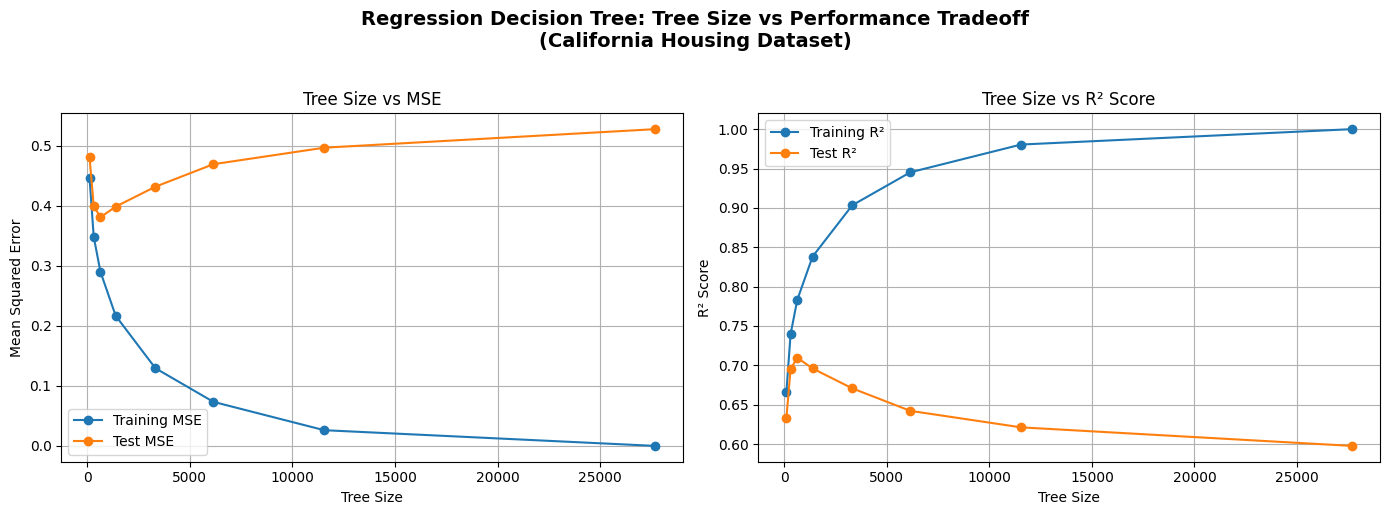

In [12]:
# Write your code here

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Tree Size vs MSE
ax1.plot(reg_tree_sizes, reg_train_mse, marker='o', label='Training MSE')
ax1.plot(reg_tree_sizes, reg_test_mse, marker='o', label='Test MSE')
ax1.set_xlabel('Tree Size')
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('Tree Size vs MSE')
ax1.legend()
ax1.grid(True)

# Plot 2: Tree Size vs R² Score
ax2.plot(reg_tree_sizes, reg_train_r2, marker='o', label='Training R²')
ax2.plot(reg_tree_sizes, reg_test_r2, marker='o', label='Test R²')
ax2.set_xlabel('Tree Size')
ax2.set_ylabel('R² Score')
ax2.set_title('Tree Size vs R² Score')
ax2.legend()
ax2.grid(True)

plt.suptitle('Regression Decision Tree: Tree Size vs Performance Tradeoff\n(California Housing Dataset)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **TASK 9: QUESTION**

Looking at the regression results, what `min_samples_split` value appears to give the best balance between model complexity and test performance? Explain your reasoning.

Based on the plots, a `min_samples_split` value around 10-50 appears to give a good balance. At very small values (2-5), the tree is very large and while training performance is nearly perfect (R² close to 1.0), test performance is lower, indicating overfitting. At very large values (200-500), both training and test performance suffer because the tree is too simple (underfitting). The intermediate values achieve a good test R² score without creating an excessively complex tree.

---
## **Summary and Key Takeaways**

### What we learned:

1. **Decision Trees**:
   - Can be used for both classification and regression tasks
   - Make predictions by recursively splitting data based on feature values
   - Easy to interpret and visualize

2. **Hyperparameter Tuning**:
   - `min_samples_split` controls tree complexity
   - Small values → large trees (more complex, risk of overfitting)
   - Large values → small trees (less complex, risk of underfitting)

3. **Bias-Variance Tradeoff**:
   - **Large trees**: Low bias, high variance (fit training data well, may not generalize)
   - **Small trees**: High bias, low variance (may miss patterns, but more stable)
   - Goal: Find the sweet spot that maximizes test performance

4. **Performance Metrics**:
   - **Classification**: Accuracy (proportion of correct predictions)
   - **Regression**: MSE (average squared error) and R² (proportion of variance explained)

5. **Overfitting Signs**:
   - Large gap between training and test performance
   - Perfect or near-perfect training performance
   - Test performance decreases as model gets more complex

### Extensions to Explore:

- Try other hyperparameters: `max_depth`, `min_samples_leaf`, `max_features`
- Use cross-validation to find optimal hyperparameters
- Visualize actual decision trees using `plot_tree()` from sklearn
- Compare with ensemble methods (Random Forest, Gradient Boosting)
- Analyze feature importances from the trained trees